In [1]:
from sketchy_cnn.dataset import ensure_hf_dataset
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import copy

ROOT_DIR = Path("sketch-vectorization")
csv_path = ROOT_DIR / "data" / "svg_dataset.csv"
csv_bytes = csv_path.read_bytes()

In [2]:
from sketchy_cnn.dataset import SVGDataset

In [3]:
D_IMAGE=256
STD_NOISE=0.02

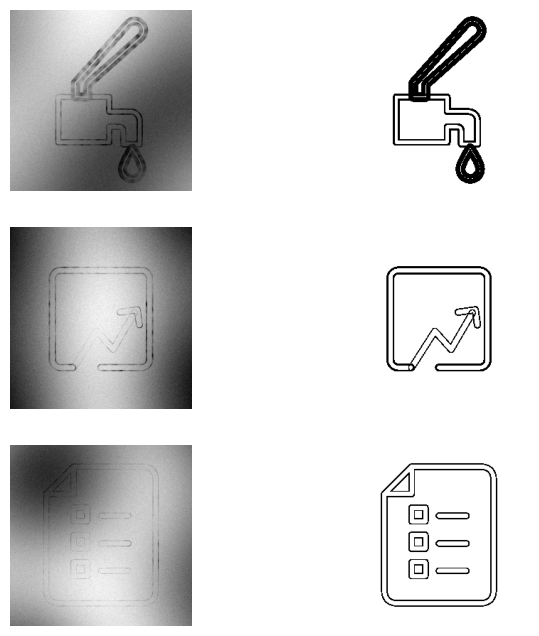

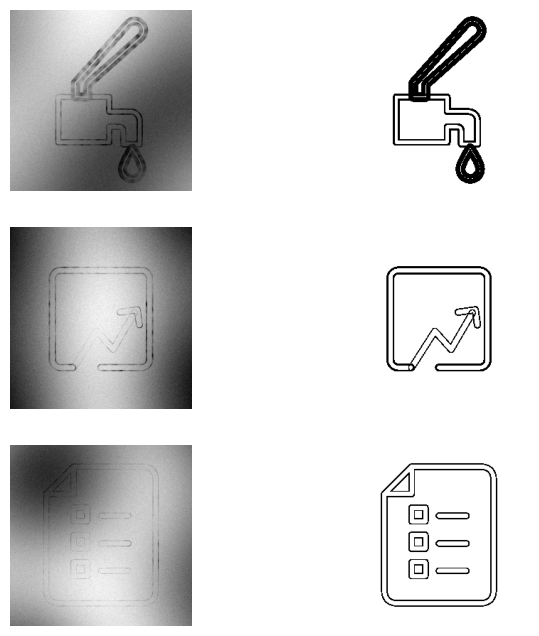

In [4]:
demo_df = pl.read_csv(csv_bytes)
demo_dataset = SVGDataset(demo_df, n=10, d=D_IMAGE, std_noise=STD_NOISE)
_fig, _axes = plt.subplots(3, 2, figsize=(8, 8))
for i in range(3):
    for j in range(2):
        _axes[i, j].imshow(demo_dataset[i][j][0], cmap="binary")
        _axes[i, j].axis(False)
_fig

In [13]:
import torch # Import torch for saving/loading

# Define a path to save/load the dataset
dataset_path = ROOT_DIR / "data" / "cached_dataset.pt" # Using ROOT_DIR defined earlier

if dataset_path.exists():
    print(f"Loading dataset from {dataset_path}")
    dataset = torch.load(dataset_path)
else:
    print("Creating dataset and saving to disk...")
    # Assuming demo_df, D_IMAGE, STD_NOISE are defined in previous cells
    dataset = SVGDataset(demo_df, n=2048, d=D_IMAGE, std_noise=STD_NOISE)
    dataset_path.parent.mkdir(parents=True, exist_ok=True) # Ensure directory exists
    torch.save(dataset, dataset_path)
    print(f"Dataset saved to {dataset_path}")

Creating dataset and saving to disk...
Dataset saved to sketch-vectorization/data/cached_dataset.pt


In [6]:
from sketchy_cnn import SketchDenoiser
import torch
import torch_xla

In [14]:
def loss_function(pred, target, lambda_weight=0.3, epsilon=1e-2):
    # False negative term (mean over batch)
    fn_loss = -(target * torch.log(pred + epsilon)).mean()

    # Energy term (mean over batch)
    energy = pred.mean()

    return fn_loss + lambda_weight * energy

In [15]:
import torch_xla.core.xla_model as xm
import copy # Explicitly import copy

class Trainer:
    def __init__(self, d_model, lr, init_state_dict=None):
        self.device = xm.xla_device() # Use xm.xla_device() for consistency
        self.model = SketchDenoiser(d_model).to(self.device)
        if init_state_dict is not None:
            self.model.load_state_dict(
                {k: v.to(self.device) for k, v in init_state_dict.items()}
            )
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)
        self.losses = []
        self.checkpoints = []

    def train(self, dataset, batch_size, n_epoch):
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        print(f"start training on {self.device}")

        for epoch in range(n_epoch):
            epoch_loss = sum(
                self._step(batch_x, batch_y)
                for batch_x, batch_y in dataloader
            ) / len(dataloader)

            self.losses.append(epoch_loss)
            # Get state_dict from the model which is on XLA device
            state_dict = self.model.state_dict()
            # Move all tensors in state_dict to CPU for checkpointing if desired
            cpu_state_dict = {k: v.cpu() for k, v in state_dict.items()}
            self.checkpoints.append(copy.deepcopy(cpu_state_dict))

            print(f"Epoch {epoch + 1}/{n_epoch}, Loss: {epoch_loss:.4f}")

            if len(self.losses) >= 3 and self.losses[-1] > self.losses[-2] > self.losses[-3]:
                print("Loss increasing for 2 epochs, early stopping")
                break

        return self.checkpoints, self.losses

    def _step(self, batch_x, batch_y):
        batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
        self.optimizer.zero_grad()
        loss = loss_function(self.model(batch_x), batch_y)
        loss.backward()
        xm.optimizer_step(self.optimizer) # Use xm.optimizer_step
        xm.mark_step() # Add xm.mark_step
        return loss.item()

    def get_state(self):
        return self.checkpoints, self.losses

In [16]:
N_EPOCH = 50
BATCH_SIZE = 32
LR = 0.005
D_MODEL = 32

In [17]:
trainer = Trainer(D_MODEL, LR)
state_dict, losses = trainer.train(dataset, BATCH_SIZE, N_EPOCH)

/tmp/ipython-input-5904/245284508.py:6: DeprecationWarning: Use torch_xla.device instead
  self.device = xm.xla_device() # Use xm.xla_device() for consistency
/tmp/ipython-input-5904/245284508.py:47: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step() # Add xm.mark_step


start training on xla:0
Epoch 1/50, Loss: 0.1456
Epoch 2/50, Loss: 0.0583
Epoch 3/50, Loss: 0.0444
Epoch 4/50, Loss: 0.0387
Epoch 5/50, Loss: 0.0373
Epoch 6/50, Loss: 0.0361
Epoch 7/50, Loss: 0.0352
Epoch 8/50, Loss: 0.0350
Epoch 9/50, Loss: 0.0346
Epoch 10/50, Loss: 0.0342
Epoch 11/50, Loss: 0.0341
Epoch 12/50, Loss: 0.0334
Epoch 13/50, Loss: 0.0334
Epoch 14/50, Loss: 0.0329
Epoch 15/50, Loss: 0.0329
Epoch 16/50, Loss: 0.0326
Epoch 17/50, Loss: 0.0324
Epoch 18/50, Loss: 0.0322
Epoch 19/50, Loss: 0.0320
Epoch 20/50, Loss: 0.0320
Epoch 21/50, Loss: 0.0317
Epoch 22/50, Loss: 0.0315
Epoch 23/50, Loss: 0.0314
Epoch 24/50, Loss: 0.0312
Epoch 25/50, Loss: 0.0311
Epoch 26/50, Loss: 0.0307
Epoch 27/50, Loss: 0.0307
Epoch 28/50, Loss: 0.0306
Epoch 29/50, Loss: 0.0304
Epoch 30/50, Loss: 0.0303
Epoch 31/50, Loss: 0.0302
Epoch 32/50, Loss: 0.0300
Epoch 33/50, Loss: 0.0300
Epoch 34/50, Loss: 0.0299
Epoch 35/50, Loss: 0.0298
Epoch 36/50, Loss: 0.0297
Epoch 37/50, Loss: 0.0297
Epoch 38/50, Loss: 0.02

<Axes: title={'center': 'Reconstruction loss'}, xlabel='Epoch', ylabel='Loss'>

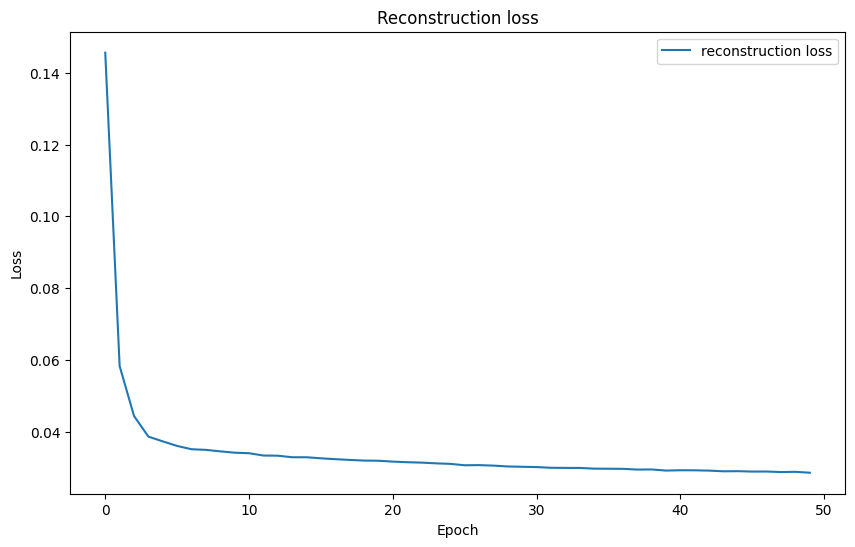

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses, label="reconstruction loss")
plt.title("Reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.gca()

In [19]:
import base64
from io import BytesIO

def figure(data, w=D_IMAGE, h=D_IMAGE, cmap="binary"):
    import matplotlib.pyplot as _plt

    fig = _plt.figure()
    ax = fig.gca()
    ax.imshow(data.reshape(h, w), cmap=cmap)
    ax.axis(False)
    buf = BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    img_b64 = base64.b64encode(buf.getvalue()).decode()
    _plt.close(fig)
    return mo.Html(f'<img src="data:image/png;base64,{img_b64}" />')

def table(data):
    import polars as pl

    df = pl.DataFrame(data)
    parts = ["<table><thead><tr>"]
    for col in df.columns:
        parts.append(f'<th style="text-align:center">{col}</th>')
    parts.append("</tr></thead><tbody>")
    for row in df.iter_rows(named=False):
        parts.append("<tr>")
        for cell in row:
            parts.append(f"<td>{cell}</td>")
        parts.append("</tr>")
    parts.append("</tbody></table>")
    return mo.Html("".join(parts))

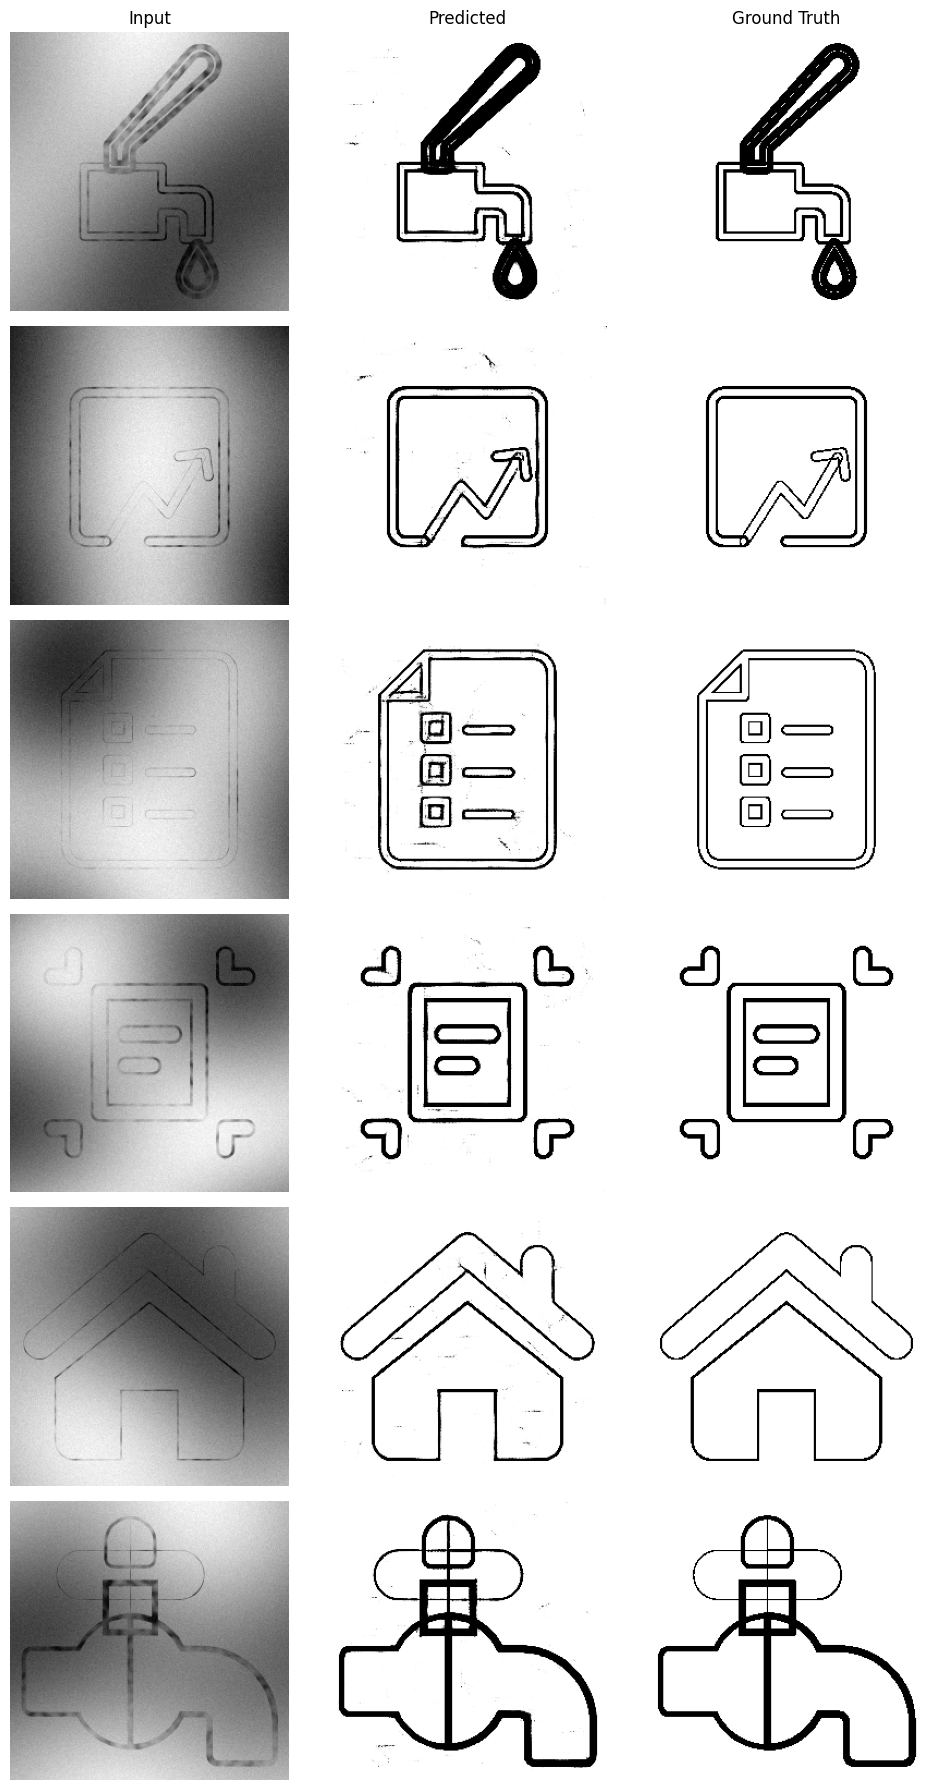

In [28]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for .numpy() conversion

model_viz = SketchDenoiser(D_MODEL) # Use D_MODEL from global scope
# Load the last model checkpoint (assuming 'losses' in kernel state holds checkpoints)
model_viz.load_state_dict({k: v.cpu() for k, v in state_dict[-1].items()})
model_viz.eval().cpu()

_samples = [demo_dataset[i] for i in range(6)]
_xs = torch.stack([s[0] for s in _samples])
_ys = torch.stack([s[1] for s in _samples])

with torch.no_grad():
    _preds = model_viz.forward(_xs) # Ensure predictions are on CPU for plotting

num_samples = len(_samples)
fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 3))

titles = ["Input", "Predicted", "Ground Truth"]

for i in range(num_samples):
    # Input
    axes[i, 0].imshow(_xs[i].squeeze().cpu().numpy(), cmap="binary")
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].set_title(titles[0])

    # Predicted
    axes[i, 1].imshow(_preds[i].squeeze().cpu().numpy(), cmap="binary")
    axes[i, 1].axis('off')
    if i == 0:
        axes[i, 1].set_title(titles[1])

    # Ground truth
    axes[i, 2].imshow(_ys[i].squeeze().cpu().numpy(), cmap="binary")
    axes[i, 2].axis('off')
    if i == 0:
        axes[i, 2].set_title(titles[2])

plt.tight_layout()
plt.show()

In [30]:
# we remove the batch dimension for onnx (we will infer one image at a time)
_dummy = torch.rand((1, 256, 256), dtype=torch.float32)
_out_path = ROOT_DIR / "src" / "sketchy_svg" / "cnn" / "model.onnx"

torch.onnx.export(
    model_viz,
    (_dummy,),
    _out_path,
    input_names=["input"],
    output_names=["output"],
    export_params=True,
    dynamic_axes={
        "input": {1: "height", 2: "width"},
        "output": {1: "height", 2: "width"},
    },
    dynamo=True,
)
print(f"Model exported to {_out_path}")

/tmp/ipython-input-5904/3897845773.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `SketchDenoiser([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SketchDenoiser([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
Model exported to sketch-vectorization/src/sketchy_svg/cnn/model.onnx
